In [2]:
import pandas as pd
import os

# Path to dataset folder
base_path = r"C:\Users\shash\OneDrive\Desktop\EdgeIIoT_Project\Edge-IIoTset dataset"

all_data = []

# Loop through each folder (Normal, DDoS, etc.)
for folder_name in os.listdir(base_path):
    folder_path = os.path.join(base_path, folder_name)

    if os.path.isdir(folder_path):
        print(f"Processing folder: {folder_name}")

        # Loop through CSV files inside folder
        for file in os.listdir(folder_path):
            if file.endswith(".csv"):
                file_path = os.path.join(folder_path, file)

                df = pd.read_csv(file_path)

                # Add label column (folder name = class)
                df["label"] = folder_name

                all_data.append(df)

# Combine all data
final_df = pd.concat(all_data, ignore_index=True)

print("Final Shape:", final_df.shape)
print(final_df.head())

Processing folder: Attack traffic


C:\Users\shash\AppData\Local\Temp\ipykernel_10708\745366951.py:21: DtypeWarning: Columns (0: arp.dst.proto_ipv4, 1: arp.src.proto_ipv4, 2: http.request.method, 3: http.referer, 4: http.request.full_uri, 5: http.request.version) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
C:\Users\shash\AppData\Local\Temp\ipykernel_10708\745366951.py:21: DtypeWarning: Columns (0: arp.dst.proto_ipv4, 1: arp.src.proto_ipv4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
C:\Users\shash\AppData\Local\Temp\ipykernel_10708\745366951.py:21: DtypeWarning: Columns (0: ip.dst_host, 1: arp.dst.proto_ipv4, 2: arp.hw.size, 3: icmp.seq_le) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
C:\Users\shash\AppData\Local\Temp\ipykernel_10708\745366951.py:21: DtypeWarning: Columns (0: http.referer) have mixed types. Specify dtype option on import or set 

Processing folder: Normal traffic
Processing folder: Selected dataset for ML and DL


C:\Users\shash\AppData\Local\Temp\ipykernel_10708\745366951.py:21: DtypeWarning: Columns (0: ip.dst_host, 1: arp.dst.proto_ipv4, 2: arp.src.proto_ipv4, 3: http.file_data, 4: http.request.uri.query, 5: http.request.method, 6: http.referer, 7: http.request.full_uri, 8: http.request.version, 9: tcp.options, 10: tcp.payload, 11: tcp.srcport, 12: dns.qry.name.len, 13: mqtt.conack.flags, 14: mqtt.msg, 15: mqtt.protoname, 16: mqtt.topic) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
C:\Users\shash\AppData\Local\Temp\ipykernel_10708\745366951.py:21: DtypeWarning: Columns (0: arp.dst.proto_ipv4, 1: arp.src.proto_ipv4, 2: http.file_data, 3: http.request.uri.query, 4: http.request.method, 5: http.referer, 6: http.request.full_uri, 7: http.request.version, 8: tcp.options, 9: tcp.payload, 10: tcp.srcport, 11: dns.qry.name.len, 12: mqtt.conack.flags, 13: mqtt.msg, 14: mqtt.protoname, 15: mqtt.topic) have mixed types. Specify dtype option on i

Final Shape: (12106710, 64)
                  frame.time    ip.src_host    ip.dst_host arp.dst.proto_ipv4  \
0   2021 17:58:23.150209000   192.168.0.128  192.168.0.170                  0   
1   2021 17:58:23.150231000   192.168.0.128  192.168.0.170                  0   
2   2021 17:58:23.166306000   192.168.0.170  192.168.0.128                  0   
3   2021 17:58:23.269052000               0              0                  0   
4   2021 17:58:23.659941000   192.168.0.128  192.168.0.170                  0   

   arp.opcode arp.hw.size arp.src.proto_ipv4 icmp.checksum icmp.seq_le  \
0         0.0         0.0                  0           0.0         0.0   
1         0.0         0.0                  0           0.0         0.0   
2         0.0         0.0                  0           0.0         0.0   
3         0.0         0.0                  0           0.0         0.0   
4         0.0         0.0                  0           0.0         0.0   

   icmp.transmit_timestamp  ...  mqtt.pr

In [3]:
import os

print(os.listdir(base_path))

['Attack traffic', 'Normal traffic', 'Selected dataset for ML and DL']


In [3]:
# -------------------- DATA CLEANING --------------------

# Remove duplicate rows
# WHY: Duplicate data can bias the model and reduce accuracy
final_df = final_df.drop_duplicates()

# Check missing values
# WHY: Missing values can break ML models
print("Missing values:\n", final_df.isnull().sum())

# Fill missing values with 0
# WHY: Simple and fast method for large datasets like this
final_df = final_df.fillna(0)

print("Shape after cleaning:", final_df.shape)

Missing values:
 frame.time            0
ip.src_host           0
ip.dst_host           0
arp.dst.proto_ipv4    0
arp.opcode            0
                     ..
mbtcp.trans_id        0
mbtcp.unit_id         0
Attack_label          0
Attack_type           0
label                 0
Length: 64, dtype: int64
Shape after cleaning: (12049008, 64)


In [4]:
# Check duplicates count before removing
print("Duplicate rows before:", final_df.duplicated().sum())

# Remove duplicates
final_df = final_df.drop_duplicates()

# Check again
print("Duplicate rows after:", final_df.duplicated().sum())

Duplicate rows before: 0
Duplicate rows after: 0


In [5]:
# -------------------- STEP 4: LABEL ENCODING --------------------

from sklearn.preprocessing import LabelEncoder

# Convert text labels into numeric values
# WHY: Machine learning models require numerical input

le = LabelEncoder()
final_df["label"] = le.fit_transform(final_df["label"])

# Check result
print("Unique labels:", final_df["label"].unique())

Unique labels: [0 1]


In [6]:
# -------------------- STEP 5: KEEP ONLY NUMERIC DATA --------------------

import numpy as np

# Check data types
print("Before:\n", final_df.dtypes)

# Keep only numeric columns
# WHY: ML algorithms require numerical input
final_df = final_df.select_dtypes(include=[np.number])

# Check after removal
print("\nAfter:\n", final_df.dtypes)

print("\nRemaining columns:", final_df.columns)

Before:
 frame.time             object
ip.src_host               str
ip.dst_host            object
arp.dst.proto_ipv4     object
arp.opcode            float64
                       ...   
mbtcp.trans_id        float64
mbtcp.unit_id         float64
Attack_label            int64
Attack_type               str
label                   int64
Length: 64, dtype: object

After:
 arp.opcode                   float64
icmp.transmit_timestamp      float64
icmp.unused                  float64
http.content_length          float64
http.response                float64
http.tls_port                float64
tcp.ack                      float64
tcp.ack_raw                  float64
tcp.connection.rst           float64
tcp.connection.syn           float64
tcp.connection.synack        float64
tcp.flags.ack                float64
tcp.len                      float64
tcp.seq                      float64
udp.stream                   float64
udp.time_delta               float64
dns.qry.name                 float

In [7]:
# -------------------- STEP 6: FEATURE & TARGET SPLIT --------------------

# X = all columns except label
# WHY: These are input features used for prediction
X = final_df.drop("label", axis=1)

# y = only label column
# WHY: This is the target/output we want to predict
y = final_df["label"]

# Check shapes
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (12049008, 35)
y shape: (12049008,)


In [8]:
print(X.head())
print(y.head())

   arp.opcode  icmp.transmit_timestamp  icmp.unused  http.content_length  \
0         0.0                      0.0          0.0                  0.0   
1         0.0                      0.0          0.0                  0.0   
2         0.0                      0.0          0.0                  0.0   
3         0.0                      0.0          0.0                  0.0   
4         0.0                      0.0          0.0                  0.0   

   http.response  http.tls_port  tcp.ack   tcp.ack_raw  tcp.connection.rst  \
0            0.0            0.0      1.0  1.453307e+09                 0.0   
1            0.0            0.0      1.0  1.453307e+09                 0.0   
2            0.0            0.0   1617.0  2.578304e+09                 0.0   
3            0.0            0.0      0.0  0.000000e+00                 0.0   
4            0.0            0.0      1.0  1.453307e+09                 0.0   

   tcp.connection.syn  ...  mqtt.len  mqtt.msg_decoded_as  mqtt.msgtype  \

In [33]:
# -------------------- CREATE SAMPLE --------------------

sample_df = final_df.sample(n=200000, random_state=42)

print("Sample shape:", sample_df.shape)

Sample shape: (200000, 36)


In [34]:
# -------------------- SPLIT AGAIN USING SAMPLE --------------------

X = sample_df.drop("label", axis=1)
y = sample_df["label"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (200000, 35)
y shape: (200000,)


In [35]:
# -------------------- STEP 7: FEATURE SCALING --------------------

from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Fit and transform data
# WHY: Makes all features have mean=0 and std=1
X_scaled = scaler.fit_transform(X)

print("Scaling done ✅")
print("Shape after scaling:", X_scaled.shape)

Scaling done ✅
Shape after scaling: (200000, 35)


In [36]:
# -------------------- STEP 8: PCA --------------------

from sklearn.decomposition import PCA

# Create PCA object
# WHY: Reduce number of features while keeping important information
pca = PCA(n_components=15)

# Apply PCA on scaled data
X_pca = pca.fit_transform(X_scaled)

print("PCA done ✅")
print("Shape after PCA:", X_pca.shape)

PCA done ✅
Shape after PCA: (200000, 15)


In [37]:
# Check how much information is preserved
print("Explained Variance Ratio:\n", pca.explained_variance_ratio_)
print("Total Variance Retained:", sum(pca.explained_variance_ratio_))

Explained Variance Ratio:
 [0.14079594 0.09333992 0.08930097 0.06748451 0.0645601  0.06206534
 0.05534256 0.05232691 0.05003923 0.04208124 0.03451034 0.03340961
 0.03231434 0.03225926 0.03201634]
Total Variance Retained: 0.8818466110595893


In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (160000, 15)
Test shape: (40000, 15)


In [39]:
# -------------------- STEP 10: KNN MODEL --------------------

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Create KNN model
# WHY: Uses distance to classify data points
knn = KNeighborsClassifier(n_neighbors=5)

# Train model
knn.fit(X_train, y_train)

# Predict on test data
y_pred_knn = knn.predict(X_test)

# Calculate accuracy
accuracy_knn = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", accuracy_knn)

KNN Accuracy: 0.943925


In [40]:
# -------------------- STEP 11: RANDOM FOREST --------------------

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Create model
# WHY: Ensemble method (multiple trees) → better accuracy & stability
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Train model
rf.fit(X_train, y_train)

# Predict
y_pred_rf = rf.predict(X_test)

# Accuracy
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", accuracy_rf)

Random Forest Accuracy: 0.92275


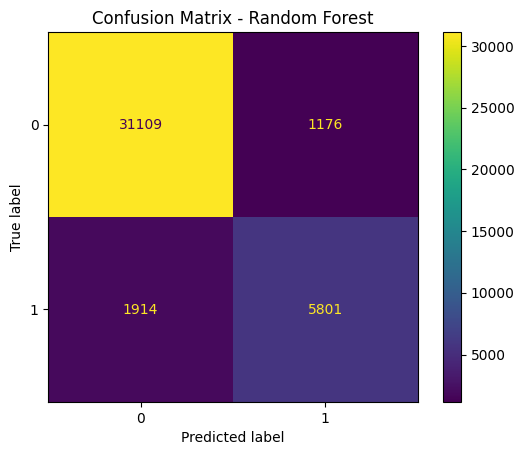

In [41]:
# -------------------- STEP 12: CONFUSION MATRIX --------------------

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create confusion matrix for Random Forest
cm = confusion_matrix(y_test, y_pred_rf)

# Display it
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix - Random Forest")
plt.show()

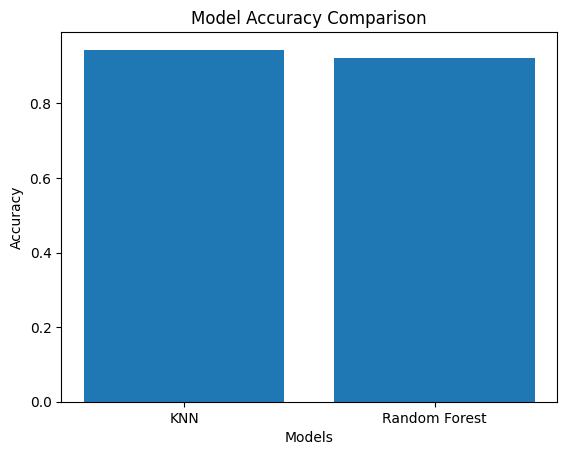

In [42]:
# -------------------- STEP 13: ACCURACY COMPARISON --------------------

models = ["KNN", "Random Forest"]
accuracies = [accuracy_knn, accuracy_rf]

plt.figure()
plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()